<a href="https://colab.research.google.com/github/liz8888-ai/week3_lab/blob/main/A85104925001_lz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE206 Fundamental of Machine Learning
## Lab: Exploring, Visualising and Cleaning Data

**Duration:** 2 hours

| Session | What happens | Dataset | Time |
|---|---|---|---|
| Session 1 | Guided walkthrough with the instructor | Titanic passengers | 60 min |
| Session 2 | Graded exercises, done on your own | Palmer penguins | 60 min, 100 marks |

### What you will learn today

1. Load a CSV file into Python with **pandas**.
2. Explore the data: size, columns, data types, summaries and missing values.
3. Draw a **histogram**, a **bar chart**, a **scatter plot** and a **heatmap of missing values**, and label the axes and the data.
4. Clean the data: remove columns, insert new columns and fill missing values.
5. Prepare the data for machine learning: choose the output column, turn text into numbers and scale the numbers.

---
# Session 2: Graded Exercises (100 marks)

## Instructions

1. Before you start, click **Runtime > Restart session** to clear the Session 1 variables. Then run the cells from Question 1 onwards.
2. Work **on your own**.
3. Write your code in the cells marked `# YOUR CODE HERE`.
4. Write your written answers in the cells that start with **Your answer:** (double-click the cell to edit it).
5. Marks for each part are shown in square brackets, for example **[3 marks]**.
6. Every chart must have a title and axis labels.
7. Before you submit, click **Runtime > Restart session and run all** and check that there are no errors.
8. Rename the file to `CSE206_Lab1_YourName`, then click **File > Download > Download .ipynb** and submit the downloaded file.

The Session 1 walkthrough above is your guide. Most questions use the same code with different column names.

| Part | Topic | Marks |
|---|---|---|
| A | Loading and exploring data | 20 |
| B | Visualising data | 25 |
| C | Cleaning and preparing data | 45 |
| D | Short theory questions | 10 |
| | **Total** | **100** |

## About the dataset

The penguins dataset has measurements of 344 penguins from three islands in Antarctica.

File address:
`https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv`

| Column | Meaning |
|---|---|
| species | Adelie, Chinstrap or Gentoo |
| island | Biscoe, Dream or Torgersen |
| bill_length_mm | Length of the beak (mm) |
| bill_depth_mm | Depth (height) of the beak (mm) |
| flipper_length_mm | Length of the flipper (wing) (mm) |
| body_mass_g | Body weight (grams) |
| sex | MALE or FEMALE |

In this lab, **species** is the output column we want to predict.

---
## Part A: Loading and Exploring Data (20 marks)

### Question 1: Load the data (5 marks)

a) Import pandas, matplotlib.pyplot and seaborn with their usual nicknames. **[1 mark]**

b) Read the penguins CSV file (address given above) into a DataFrame called `df`. **[2 marks]**

c) Show the first 5 rows. **[1 mark]**

d) Show the shape of the table. **[1 mark]**

In [25]:
# (a)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
#(b)
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
print("Data loaded")

Data loaded


In [27]:
#(c)
print(df.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


In [6]:

#(d)
df.shape

(344, 7)

### Question 2: Explore the data (10 marks)

a) Show the column names, the number of non-empty values and the data type of every column. *Hint: `info()`* **[2 marks]**

b) Show the summary statistics of the numeric columns. **[2 marks]**

c) Count how many penguins there are of each species. *Hint: `value_counts()`* **[2 marks]**

d) Calculate the average `body_mass_g` for each species. Then answer below: which species is the heaviest? *Hint: `groupby()`* **[4 marks]**

In [28]:
# YOUR CODE HERE (a)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [29]:
# YOUR CODE HERE (b)
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [30]:
# YOUR CODE HERE (c)
df["species"].value_counts()


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [31]:
# YOUR CODE HERE (d)
df.groupby("species")["body_mass_g"].mean()

,body_mass_g
species,
Adelie,3700.662252
Chinstrap,3733.088235
Gentoo,5076.016260


**Your answer:The Gentoo is the heaviest**

### Question 3: Missing values (5 marks)

a) Count the missing values in every column. **[2 marks]**

b) Draw a heatmap of the missing values with a title and axis labels. *Hint: `sns.heatmap(df.isnull(), ...)`* **[2 marks]**

c) Answer below: which column has the most missing values? **[1 mark]**

In [32]:
# YOUR CODE HERE (a)
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


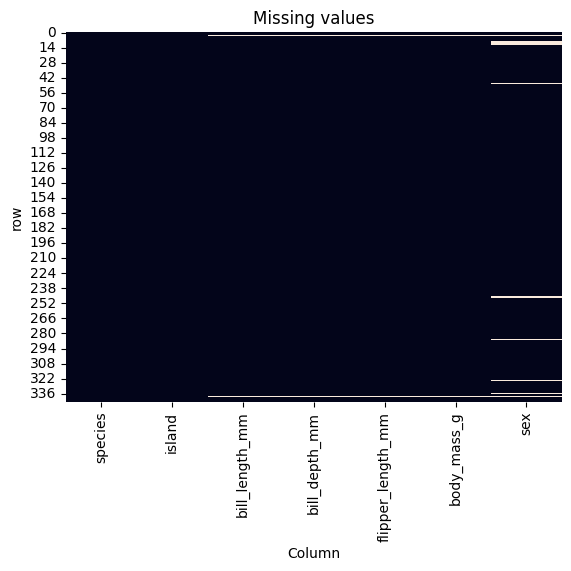

In [33]:
# YOUR CODE HERE (b)
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing values")
plt.xlabel("Column")
plt.ylabel("row")
plt.show()

**Your answer : Column sex has the most ,missing values **

---
## Part B: Visualising Data (25 marks)

Every chart must have a **title**, an **x-axis label** and a **y-axis label**.

### Question 4: Histogram (8 marks)

Draw a histogram of `flipper_length_mm`.

a) Use 20 bins. **[3 marks]**

b) Add the x-axis label and the y-axis label. **[2 marks]**

c) Add a title. **[1 mark]**

d) Answer below: how many main peaks (high areas) do you see in the histogram? **[2 marks]**

(array([ 2.,  1., 10., 12., 23., 29., 42., 37., 28., 16.,  9.,  6., 27.,
        15., 26., 16., 19.,  9.,  5., 10.]),
 array([172.  , 174.95, 177.9 , 180.85, 183.8 , 186.75, 189.7 , 192.65,
        195.6 , 198.55, 201.5 , 204.45, 207.4 , 210.35, 213.3 , 216.25,
        219.2 , 222.15, 225.1 , 228.05, 231.  ]),
 <BarContainer object of 20 artists>)

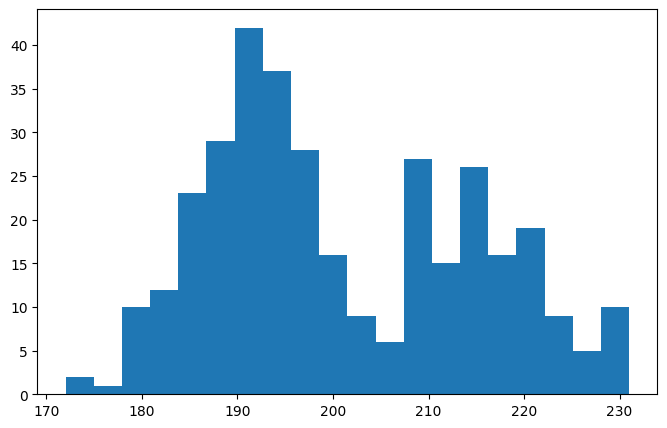

In [36]:
# YOUR CODE HERE (a)
plt.figure(figsize=(8, 5))

plt.hist(df["flipper_length_mm"], bins=20)

Text(0, 0.5, 'Number of Penguins')

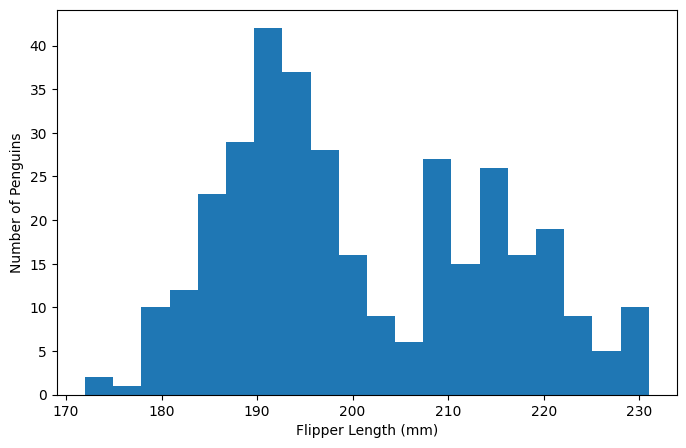

In [40]:
# YOUR CODE HERE (b)
plt.figure(figsize=(8, 5))

plt.hist(df["flipper_length_mm"], bins=20)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Number of Penguins")

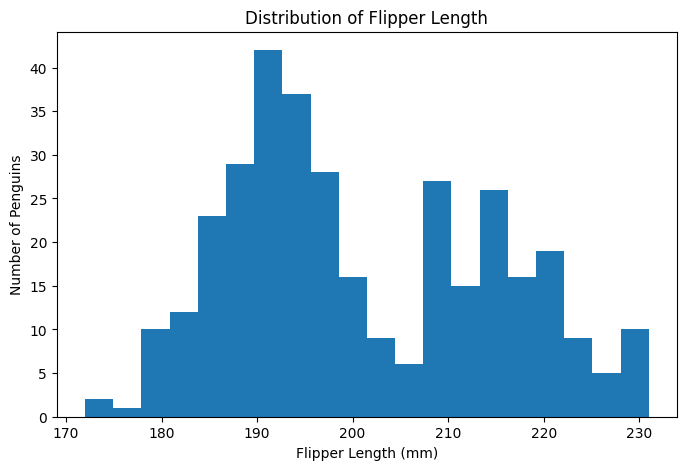

In [41]:
# YOUR CODE HERE (c)
plt.figure(figsize=(8, 5))

plt.hist(df["flipper_length_mm"], bins=20)


plt.xlabel("Flipper Length (mm)")
plt.ylabel("Number of Penguins")


plt.title("Distribution of Flipper Length")

plt.show()

**Your answer: I see 3 main peaks.**




### Question 5: Bar chart (8 marks)

Draw a bar chart that shows the **number of penguins on each island**.

a) Count the penguins on each island and draw the bars. *Hint: `value_counts()` then `plt.bar()`* **[3 marks]**

b) Add the title and both axis labels. **[2 marks]**

c) Write the count on top of each bar. *Hint: `plt.bar_label()`* **[3 marks]**

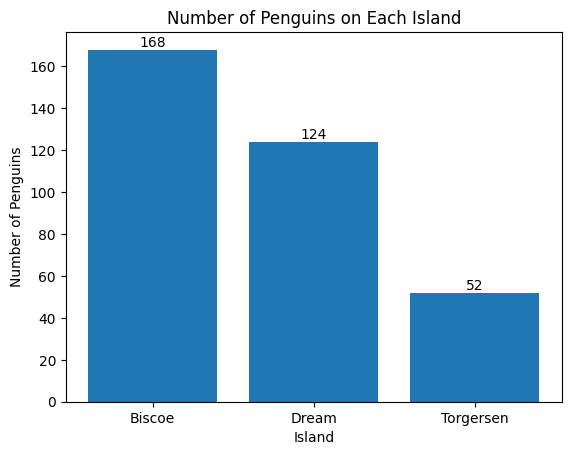

In [46]:
# YOUR CODE HERE (a)

# Count penguins on each island
island_counts = df["island"].value_counts()

bars = plt.bar(island_counts.index, island_counts.values)

# Add title and axis labels (b)
plt.title("Number of Penguins on Each Island")
plt.xlabel("Island")
plt.ylabel("Number of Penguins")

# Add counts on top of each bar (c)
plt.bar_label(bars)

plt.show()

### Question 6: Scatter plot (9 marks)

a) Draw a scatter plot with `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis, with the dots coloured by `species`. *Hint: `sns.scatterplot(..., hue="species")`* **[4 marks]**

b) Add the title and both axis labels. **[2 marks]**

c) Answer below: can the three species be told apart using only these two measurements? Explain in one or two sentences. **[3 marks]**

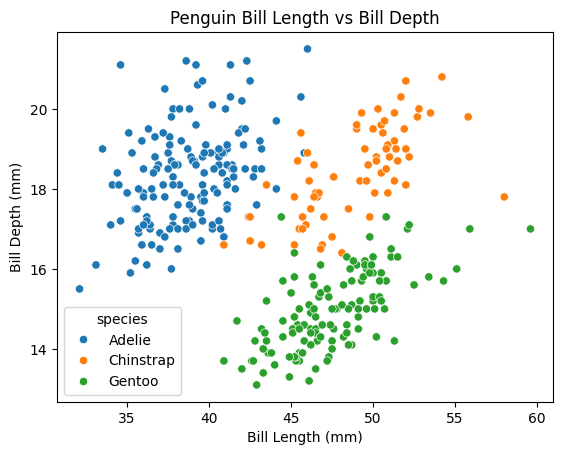

In [48]:
# YOUR CODE HERE
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)

# Title and axis labels
plt.title("Penguin Bill Length vs Bill Depth")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")

plt.show()

**Your answer: No. The species have similar bill sizes, so we cannot tell them apart exactly.**

---
## Part C: Cleaning and Preparing Data (45 marks)

### Question 7: Insert and remove columns (8 marks)

a) Add a new column `body_mass_kg` equal to `body_mass_g` divided by 1000. **[2 marks]**

b) Use `df.insert()` to add a column called `penguin_id` as the **first** column, with the numbers 1, 2, 3, ... up to the number of rows. **[3 marks]**

c) Remove the `body_mass_g` column, because `body_mass_kg` now holds the same information. Show the first 5 rows. **[3 marks]**

In [49]:
# YOUR CODE HERE
# a)
df["body_mass_kg"] = df["body_mass_g"] / 1000

# b)
df.insert(0, "penguin_id", range(1, len(df) + 1))

# c)
df = df.drop("body_mass_g", axis=1)

df.head()

,penguin_id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex,body_mass_kg
0,1,Adelie,Torgersen,39.1,18.7,181.0,MALE,3.75
1,2,Adelie,Torgersen,39.5,17.4,186.0,FEMALE,3.80
2,3,Adelie,Torgersen,40.3,18.0,195.0,FEMALE,3.25
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,5,Adelie,Torgersen,36.7,19.3,193.0,FEMALE,3.45


### Question 8: Fill missing values (10 marks)

a) Fill the missing values in the four numeric columns (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_kg`) with the **median** of each column. Use one line for each column. **[4 marks]**

b) Fill the missing values in `sex` with the **mode** (most frequent value). **[2 marks]**

c) Show that no missing values are left, with numbers. **[2 marks]**

d) Draw the missing-values heatmap again to show that no yellow is left. **[2 marks]**

In [50]:
# YOUR CODE HERE (a) and (b)

df["bill_length_mm"] = df["bill_length_mm"].fillna(df["bill_length_mm"].median())

df["bill_depth_mm"] = df["bill_depth_mm"].fillna(df["bill_depth_mm"].median())

df["flipper_length_mm"] = df["flipper_length_mm"].fillna(df["flipper_length_mm"].median())

df["body_mass_kg"] = df["body_mass_kg"].fillna(df["body_mass_kg"].median())


most_common_sex = df["sex"].mode()[0]
print("Most common sex:", most_common_sex)

df["sex"] = df["sex"].fillna(most_common_sex)



Most common sex: MALE


In [51]:
# YOUR CODE HERE (c)
df.isnull().sum()

,0
penguin_id,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
sex,0
body_mass_kg,0


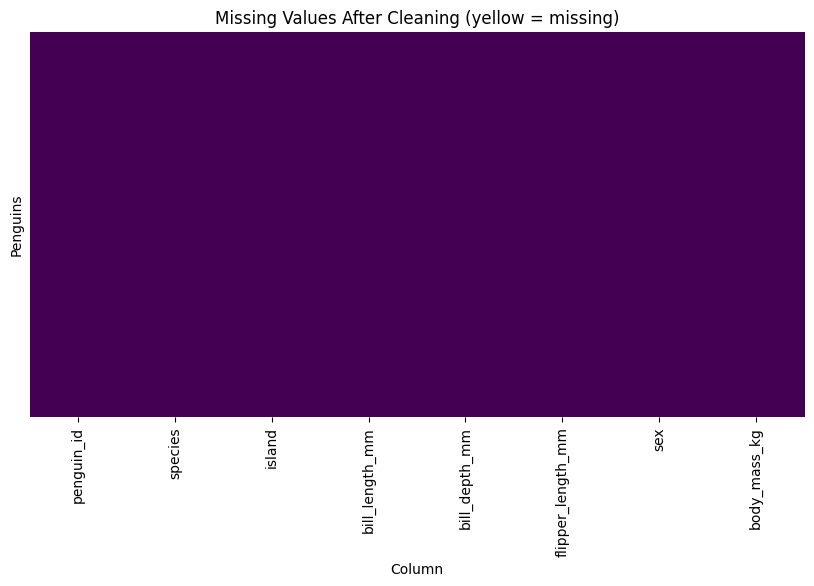

In [52]:
# YOUR CODE HERE (d)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values After Cleaning (yellow = missing)")
plt.xlabel("Column")
plt.ylabel("Penguins")
plt.show()

### Question 9: Label the output column (9 marks)

a) Create `X` with all columns **except** `species` and `penguin_id`. Create `y` with only the `species` column. **[3 marks]**

b) The output is text. Use `map()` to turn it into numbers: Adelie = 0, Chinstrap = 1, Gentoo = 2. Store the result back in `y`. **[4 marks]**

c) Count how many times each number appears in `y`. The counts should match your answer to Question 2(c). **[2 marks]**

In [53]:
# YOUR CODE HERE
# a)

y = df["species"]

X = df.drop(columns=["species", "penguin_id"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()
# b)
y = y.map({
    "Adelie": 0,
    "Chinstrap": 1,
    "Gentoo": 2
})

print(y.head())

# c)

print(y.value_counts())

X shape: (344, 6)
y shape: (344,)
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64
species
0    152
2    124
1     68
Name: count, dtype: int64


### Question 10: Encode categorical values (9 marks)

a) Turn the `sex` column of `X` into numbers: MALE = 0, FEMALE = 1. **[3 marks]**

b) Use one-hot encoding on the `island` column of `X`, with 0 and 1 values. *Hint: `pd.get_dummies(X, columns=[...], dtype=int)`* **[4 marks]**

c) Show the first 5 rows of `X` and answer below: how many columns does `X` have now? **[2 marks]**

In [54]:
# YOUR CODE HERE
#a
X["sex"] = X["sex"].map({"male": 0, "female": 1})
#b
X = pd.get_dummies(X, columns=["island"], dtype=int)
#c
X.head()
#then:
X.shape[1]


8

**Your answer: Now it has 8 columns**